In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load dataset
netflix = pd.read_csv("netflix_cleaned.csv")
custom_palette =['#E50914', '#221f1f', '#141414', '#B20710']


In [71]:
print("Shape:" , netflix.shape)

Shape: (8794, 11)


In [72]:
# Dataset Information
print(netflix.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8794 entries, 0 to 8793
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8794 non-null   object
 1   type          8794 non-null   object
 2   title         8794 non-null   object
 3   cast          8794 non-null   object
 4   country       8794 non-null   object
 5   date_added    8794 non-null   object
 6   release_year  8794 non-null   int64 
 7   rating        8794 non-null   object
 8   duration      8794 non-null   object
 9   listed_in     8794 non-null   object
 10  description   8794 non-null   object
dtypes: int64(1), object(10)
memory usage: 755.9+ KB
None


In [73]:
# First 5 rows
print(netflix.head())

  show_id     type                  title  \
0      s1    Movie   Dick Johnson Is Dead   
1      s2  TV Show          Blood & Water   
2      s3  TV Show              Ganglands   
3      s4  TV Show  Jailbirds New Orleans   
4      s5  TV Show           Kota Factory   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                            Unknown        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021          2021  TV-MA   1 Season   
3  September 24, 2021          2021  TV-MA   1 Season   
4  September 24, 

In [74]:
# Missing values
print(netflix.isnull().sum())

show_id         0
type            0
title           0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [75]:
# Statistical Summary
print("\nSummary Statistics:")
print(df.describe(include='all'))


Summary Statistics:
       show_id   type                 title     cast        country  \
count     8794   8794                  8794     8794           8794   
unique    8794      2                  8794     7682            749   
top         s1  Movie  Dick Johnson Is Dead  Unknown  United States   
freq         1   6128                     1      825           2809   
mean       NaN    NaN                   NaN      NaN            NaN   
std        NaN    NaN                   NaN      NaN            NaN   
min        NaN    NaN                   NaN      NaN            NaN   
25%        NaN    NaN                   NaN      NaN            NaN   
50%        NaN    NaN                   NaN      NaN            NaN   
75%        NaN    NaN                   NaN      NaN            NaN   
max        NaN    NaN                   NaN      NaN            NaN   

             date_added  release_year rating  duration  \
count              8794   8794.000000   8794      8794   
unique    

In [76]:
print(netflix["type"].unique())
print(netflix["rating"].unique())
print(netflix["country"].nunique())
print(netflix["release_year"].min())
print(netflix["release_year"].max())

['Movie' 'TV Show']
['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' 'NR' 'TV-Y7-FV' 'UR']
749
1925
2021


 # Step 2: Identify key content trends and patterns

In [77]:
# Content type split
#normalize=True = a parameter that converts counts into proportions (fractions of the whole, here as percentages) instead of raw numbers.
type_dist = netflix['type'].value_counts(normalize=True) * 100   # normalize=True gives proportions instead of raw counts
type_dist


type
Movie      69.683875
TV Show    30.316125
Name: proportion, dtype: float64

In [78]:
#top countries
df_country = df.assign(country=df['country'].str.split(', ')).explode('country')
df_country['country'] = df_country['country'].str.strip()

# Remove 'Unknown' BEFORE ranking, so it can never appear in top 5
top_countries = df_country[df_country['country'] != 'Unknown']['country'].value_counts().head(5)

print(top_countries)

country
United States     3680
India             1046
United Kingdom     803
Canada             445
France             393
Name: count, dtype: int64


In [79]:
top5_list = top_countries.index.tolist()
df_top5 = df_country[df_country['country'].isin(top5_list)]  

In [80]:
# Yearly trend
yearly_trend = netflix['release_year'].value_counts().sort_index()
yearly_trend

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1031
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

In [81]:
# Top genres
df_genre = netflix.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in')
top_genres = df_genre['listed_in'].str.strip().value_counts().head(5)
print(top_genres)

listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1350
Documentaries              869
Name: count, dtype: int64


In [82]:
# Rating distribution
rating_dist = df['rating'].value_counts()
rating_dist

rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

# Step 3: Develop multiple visual dashboard

C:\Users\Manmohan\AppData\Local\Temp\ipykernel_9280\1651137626.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', ax=axes[0,0], palette=custom_palette)
C:\Users\Manmohan\AppData\Local\Temp\ipykernel_9280\1651137626.py:4: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.countplot(data=df, x='type', ax=axes[0,0], palette=custom_palette)
C:\Users\Manmohan\AppData\Local\Temp\ipykernel_9280\1651137626.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0,1], palette=custom_palette)
C:\Users\Manmohan\AppData\Local\Temp\ipykernel_9280\1651137626.py:8: UserWarning: 
The p

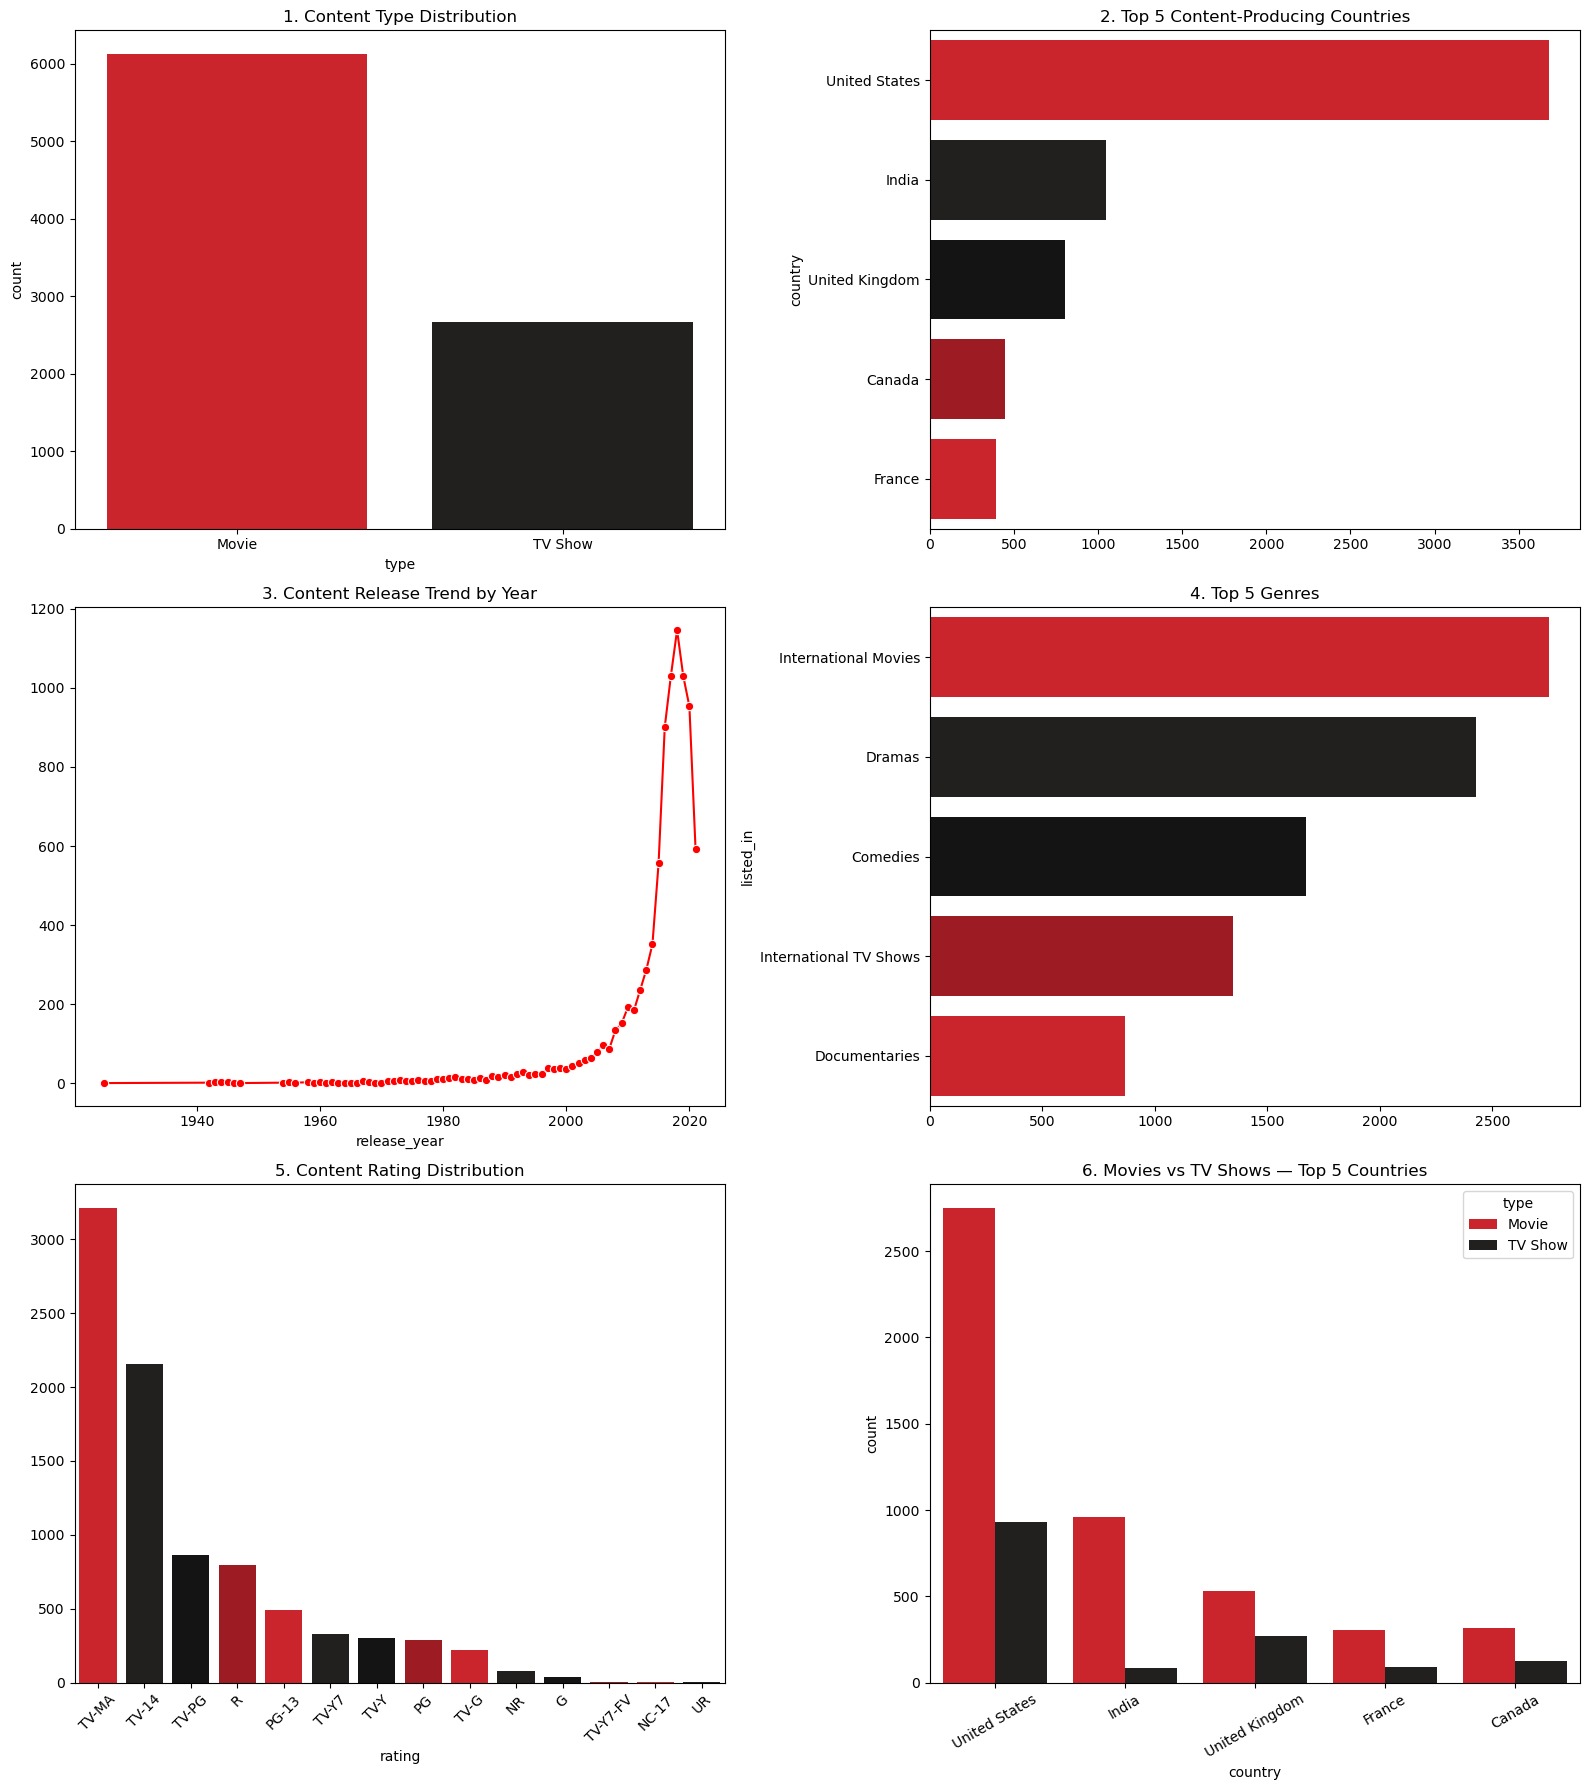

In [83]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))   # changed to 3 rows x 2 columns = 6 charts

# 1. Content type distribution
sns.countplot(data=df, x='type', ax=axes[0,0], palette=custom_palette)
axes[0,0].set_title("1. Content Type Distribution")

# 2. Top 5 countries
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0,1], palette=custom_palette)
axes[0,1].set_title("2. Top 5 Content-Producing Countries")

# 3. Yearly release trend
sns.lineplot(x=yearly_trend.index, y=yearly_trend.values, ax=axes[1,0], marker='o', color='red')
axes[1,0].set_title("3. Content Release Trend by Year")

# 4. Top 5 genres
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[1,1], palette=custom_palette)
axes[1,1].set_title("4. Top 5 Genres")

# 5. Rating distribution
sns.barplot(x=rating_dist.index, y=rating_dist.values, ax=axes[2,0], palette=custom_palette)
axes[2,0].set_title("5. Content Rating Distribution")
axes[2,0].tick_params(axis='x', rotation=45)

# 6. Movies vs TV Shows by top 5 countries 
sns.countplot(data= df_top5, x='country', hue='type', ax=axes[2,1], palette=custom_palette)
axes[2,1].set_title("6. Movies vs TV Shows — Top 5 Countries")
axes[2,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("netflix_dashboard.png", dpi=300)
plt.show()

# Step 4: Generate actionable business insights

In [84]:
insights = []

insights.append(f"Movies make up {type_dist.get('Movie', 0):.1f}% of content vs {type_dist.get('TV Show', 0):.1f}% TV Shows — Netflix's catalog is movie-heavy.")
insights.append(f"{top_countries.index[0]} is the top content-producing country with {top_countries.iloc[0]} titles.")
insights.append(f"Content releases peaked around {yearly_trend.idxmax()}, suggesting aggressive catalog expansion that year.")
insights.append(f"'{top_genres.index[0]}' is the most common genre, indicating strong audience demand in that category.")
insights.append(f"'{rating_dist.idxmax()}' is the most common content rating, showing a lean toward that target audience.")

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

1. Movies make up 69.7% of content vs 30.3% TV Shows — Netflix's catalog is movie-heavy.
2. United States is the top content-producing country with 3680 titles.
3. Content releases peaked around 2018, suggesting aggressive catalog expansion that year.
4. 'International Movies' is the most common genre, indicating strong audience demand in that category.
5. 'TV-MA' is the most common content rating, showing a lean toward that target audience.
